In [1]:
import glob
import os
import librosa
import numpy as np
import cv2
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedShuffleSplit
import tensorflow as tf
from tensorflow.keras import layers, models

# Path to the metadata file
metadata_file_path = r'D:\download\Compressed\DF-keys-full\keys\DF\CM\trial_metadata.txt'

# Dictionary to hold file identifiers and labels
labels = {}

# Open and read the metadata file
with open(metadata_file_path, 'r') as f:
    for line in f:
        parts = line.strip().split()
        file_identifier = parts[1]  # Example: DF_E_2000011
        label = parts[5]            # Example: "spoof"
        labels[file_identifier] = label

# Directory containing the undersampled audio files
undersampled_audio_dir = r'D:\audio_files\undersampled_audio'

# Find all .flac files in the undersampled directory
audio_files = glob.glob(os.path.join(undersampled_audio_dir, '*.flac'))

# Create a list to store only those files that have corresponding labels in the metadata
valid_audio_files = []
valid_labels = []

# Loop through the audio files and match with metadata labels
for audio_file in audio_files:
    file_name = os.path.basename(audio_file)
    file_identifier = file_name.split('.')[0]  # Extract the file identifier (before the extension)

    # Check if the file identifier exists in the metadata labels
    if file_identifier in labels:
        valid_audio_files.append(audio_file)  # Keep this audio file
        valid_labels.append(labels[file_identifier])  # Store the corresponding label (spoof/bonafide)

# Print the number of matching files
print(f"Found {len(valid_audio_files)} audio files with corresponding labels.")

# Audio to MFCC conversion function
def audio_to_mfcc(audio_file, sr=22050, n_mfcc=13):
    """Convert audio to MFCC."""
    audio, sample_rate = librosa.load(audio_file, sr=sr)
    mfcc = librosa.feature.mfcc(y=audio, sr=sample_rate, n_mfcc=n_mfcc)
    return mfcc

# Resize the MFCC to a fixed size function
def resize_spectrogram(spectrogram, target_size=(128, 128)):
    """Resize the MFCC to a fixed size."""
    return cv2.resize(spectrogram, target_size)

# Preprocessing the audio files
def preprocess_audio_files(audio_files, labels, target_size=(128, 128)):
    """Convert audio files to MFCCs, resize, and normalize them."""
    mfcc_data = []
    label_data = []

    for audio_file, label in zip(audio_files, labels):
        mfcc = audio_to_mfcc(audio_file)
        resized_mfcc = resize_spectrogram(mfcc, target_size)
        
        # Safe normalization: Check if the max value is 0
        max_value = np.max(resized_mfcc)
        if max_value > 0:
            normalized_mfcc = resized_mfcc / max_value
        else:
            normalized_mfcc = resized_mfcc  # Leave it as is if the max is 0

        mfcc_data.append(normalized_mfcc)
        label_data.append(1 if label == 'spoof' else 0)  # Binary label (1: spoof, 0: bonafide)

    return np.array(mfcc_data), np.array(label_data)

# Preprocess the valid audio files and labels
X, y = preprocess_audio_files(valid_audio_files, valid_labels, target_size=(128, 128
                                                                            ))

# Add a channel dimension for CNN
X = np.expand_dims(X, axis=-1)


Found 45234 audio files with corresponding labels.


In [2]:
# Stratified 70:30 train-test split
def stratified_split_70_30(X, y, test_size=0.3, random_state=42):
    """Split dataset into stratified 70/30 sets."""
    strat_split = StratifiedShuffleSplit(n_splits=1, test_size=test_size, random_state=random_state)
    
    for train_idx, test_idx in strat_split.split(X, y):
        X_train, y_train = X[train_idx], y[train_idx]
        X_test, y_test = X[test_idx], y[test_idx]
    
    # Ensure that the training set has balanced classes
    class_counts = np.bincount(y_train)
    min_class_count = min(class_counts)
    spoof_indices = np.where(y_train == 1)[0][:min_class_count]
    bonafide_indices = np.where(y_train == 0)[0][:min_class_count]
    balanced_train_indices = np.concatenate([spoof_indices, bonafide_indices])
    X_train_balanced, y_train_balanced = X_train[balanced_train_indices], y_train[balanced_train_indices]

    return X_train_balanced, X_test, y_train_balanced, y_test

# Perform the stratified 80/30 split
X_train, X_test, y_train, y_test = stratified_split_70_30(X, y, test_size=0.3, random_state=42)

# Print the distribution of classes to verify stratification
print(f"Training set distribution: {np.bincount(y_train)}")
print(f"Test set distribution: {np.bincount(y_test)}")

Training set distribution: [15831 15831]
Test set distribution: [6786 6785]


d:\download\fyp\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
d:\download\fyp\.venv\Lib\site-packages\keras\src\layers\activations\leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 16)   │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 63, 63, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 30, 30, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,605,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,629,185 (6.21 MB)

 Trainable params: 1,629,185 (6.21 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
495/495 ━━━━━━━━━━━━━━━━━━━━ 103s 204ms/step - accuracy: 0.7562 - loss: 0.5060 - val_accuracy: 0.8260 - val_loss: 0.3755
Epoch 2/100
495/495 ━━━━━━━━━━━━━━━━━━━━ 107s 216ms/step - accuracy: 0.8376 - loss: 0.3513 - val_accuracy: 0.8766 - val_loss: 0.2650
Epoch 3/100
495/495 ━━━━━━━━━━━━━━━━━━━━ 101s 204ms/step - accuracy: 0.9080 - loss: 0.2142 - val_accuracy: 0.9443 - val_loss: 0.1446
Epoch 4/100
495/495 ━━━━━━━━━━━━━━━━━━━━ 102s 207ms/step - accuracy: 0.9542 - loss: 0.1197 - val_accuracy: 0.9653 - val_loss: 0.1041
Epoch 5/100
495/495 ━━━━━━━━━━━━━━━━━━━━ 103s 209ms/step - accuracy: 0.9739 - loss: 0.0751 - val_accuracy: 0.9684 - val_loss: 0.0900
Epoch 6/100
495/495 ━━━━━━━━━━━━━━━━━━━━ 101s 205ms/step - accuracy: 0.9781 - loss: 0.0570 - val_accuracy: 0.9699 - val_loss: 0.0880
Epoch 7/100
495/495 ━━━━━━━━━━━━━━━━━━━━ 101s 203ms/step - accuracy: 0.9858 - loss: 0.0389 - val_accuracy: 0.9741 - val_loss: 0.0871
Epoch 8/100
495/495 ━━━━━━━━━━━━━━━━━━━━ 100s 202ms/step - accuracy: 

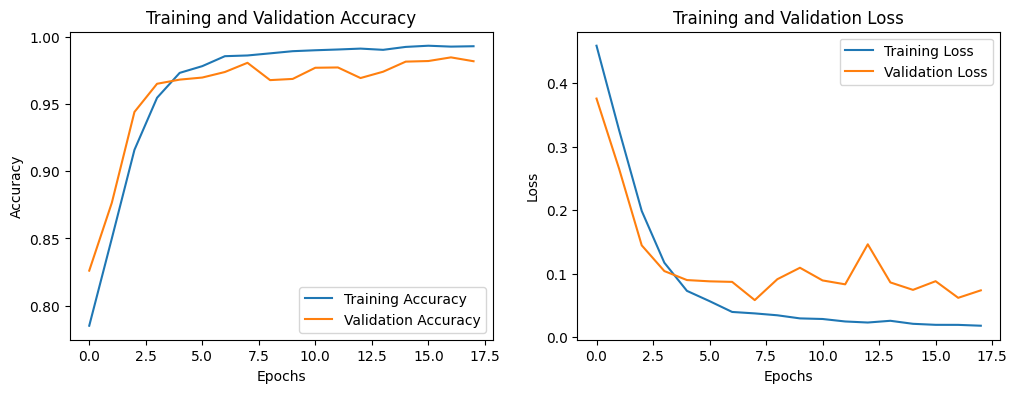

In [3]:
from tensorflow.keras.layers import LeakyReLU
from tensorflow.keras.optimizers import AdamW
from tensorflow.keras.callbacks import EarlyStopping
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# Define the CNN architecture
def build_cnn(input_shape):
    model = models.Sequential()
    
    # 1st Convolutional Layer
    model.add(layers.Conv2D(16, kernel_size=(3, 3), input_shape=input_shape))
    model.add(layers.MaxPooling2D(pool_size=(2, 2)))
    model.add(LeakyReLU(alpha=0.001))

    # 2nd Convolutional Layer
    model.add(layers.Conv2D(32, kernel_size=(3, 3), activation='relu'))
    model.add(layers.MaxPooling2D(pool_size=(2, 2)))
    model.add(LeakyReLU(alpha=0.001))

    # 3rd Convolutional Layer
    model.add(layers.Conv2D(64, kernel_size=(3, 3), activation='relu'))
    model.add(layers.MaxPooling2D(pool_size=(2, 2)))
    model.add(LeakyReLU(alpha=0.001))

    # Flatten the output and add fully connected layers
    model.add(layers.Flatten())
    model.add(layers.Dense(128, activation='relu'))
    model.add(layers.Dropout(0.3))

    # Output layer (binary classification)
    model.add(layers.Dense(1, activation='sigmoid'))

    # Compile the model
    model.compile(optimizer='AdamW', loss='binary_crossentropy', metrics=['accuracy'])
    
    return model
# Create the model with the modified parameters
input_shape = (128, 128, 1)  # Shape of input (height, width, channels)
model = build_cnn(input_shape)

# Print model summary
model.summary()

# Set up early stopping to prevent overfitting
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train the model with early stopping, using the RGB data
history = model.fit(X_train, y_train, epochs=100, batch_size=64, validation_data=(X_test, y_test), callbacks=[early_stopping])

# Evaluate the model on the test set
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"Test accuracy: {test_accuracy:.2f}")

# Plot training & validation accuracy and loss
plt.figure(figsize=(12, 4))

# Plot accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()